In [2]:
%reset -f
%run pylib/agn_steps

# Observation of steps in gamma-ray light curves

By a "step" we mean a change, typically around a factor or two in flux, within a week.

<h5 style="text-align:right; margin-right:15px"> 2025-06-14 10:03</h5>

## Load light curve data
Note that the file `source_info_v3.pkl`, used here was copied from SLAC's s3df,
where is was last updated on Jun  6 12:45. 
It can be found at `/sdf/home/b/burnett/work/bb_light_curves/files`.

* Loaded wtlike-generated variability info for 8677 sources from file `files/source_info_v3.pkl`

* Load uw1410 and 4FGL-DR4 info for the 8677 sources 

Loaded UW model uw1410: 11786 entries
Loaded Fermi 4FGL gll_psc_v32.fit: 7195 entries


* a 7105 4FGL-DR4 point sources from `gll_psc_v32.fit`

* Categorize according to the "class1" value:

   bll     1469
   fsrq     799
   bcu     1579
   unid    2178
   psr      314


* Matched 7105 DR4 with the 8677  UW, of which 6702 are unique. 

* Created match df w/ 7105 entries

,id_uw,delta
id_fgl,,
0,2.0,0.017568
1,4.0,0.069205
2,8673.0,0.580895
3,7.0,0.018705
4,6.0,0.000796


* picked 385 closest of 788 duplicates

,id_uw,delta,dup
id_fgl,,,
16,21.0,0.016135,True
60,73.0,0.919926,True
71,75.0,0.016131,True
106,113.0,0.011015,True
123,131.0,0.038321,True


combine 6317 nondup, with 385 best dups

,id_uw,delta,dup
id_fgl,,,
0,2.0,0.017568,False
1,4.0,0.069205,False
3,7.0,0.018705,False
4,6.0,0.000796,False
5,8.0,0.011551,False


,id_uw,delta
count,6702.000000,6702.000000
mean,4223.931364,0.048920
std,2520.755117,0.150165
min,0.000000,0.000001
25%,2117.250000,0.008438
50%,4101.000000,0.018584
75%,6429.000000,0.038032
max,8675.000000,2.775761


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x724c7d855b10>
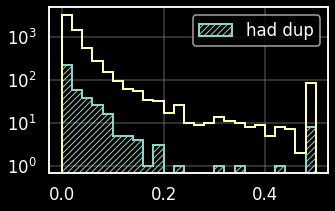

## Generate table of uw sources with DR4 counterparts
Add ...

* Categorize according to the "class1" value:

   bll     1469
   fsrq     799
   bcu     1579
   unid    2178
   psr      314


Collection of variability info for 8677 sources

In [3]:
vdb.matchup(debug=True)

In [ ]:
dfxx = select_single_step(dfx)


### Detect the single-steppers
Here I select BB light curves with exactly two blocks, and record the ratio
of the two levels and the position of the transition.
The light curves were generated with a bin width of 7 days, so the "step" position
must be at a bin boundary, the boundary position depending on the BB algorithm, its uncertainty TBD.

Apply margin=500 days: <br>Found 547 candidates, with the association categories

,bcu,bll,fsrq,other,psr,unid
all,1579,1469,799,363,314,2178
1-step,140,153,20,25,19,190


In [43]:
tdf = pd.DataFrame(
    [
    (a:=pd.Series(dict(list(zip(*np.unique(dfx.association,  return_counts=True)))), name='all')),
    (b:=pd.Series(dict(list(zip(*np.unique(dfxx.association,  return_counts=True)))), name='1-step',)),
    pd.Series(round(100*b/a), name='%'),
    ]
,dtype=int)
show(tdf)


,bcu,bll,fsrq,other,psr,unid
all,1579,1469,799,363,314,2178
1-step,140,153,20,25,19,190
%,9,10,3,7,6,9


In [22]:
def select_single_step(dfx, margin=500):
    show("""### Select the single-steppers
Here I select BB light curves with exactly two blocks, and record the ratio
of the two levels and the position of the transition.
The light curves were generated with a bin width of 7 days, so the "step" position
must be at a bin boundary, the boundary position depending on the BB algorithm, its uncertainty TBD.
""")
    ass = dfx.association.values
    tss = dfx.ts.values
    names = dfx.index
    def make_df(x):
        if x is None: return None
        return pd.DataFrame.from_dict(x)
    lcs = [make_df(vdb[uw_name]['light_curve']) for uw_name in dfx.uw_name]
    
    dd = dict()
    for name, lc, stype, ts in zip(names, lcs, ass, tss):
        if lc is None or len(lc)!=2: continue
        v = lc.tw.values
        a,b = lc.flux.values # needed after rename column [:,0]
        if (a*b>0) & (v[0]>=margin) & (v[-1]>=margin):
            dd[name] = dict(flux_ratio=b/a, time=v[0], t2=v[-1],
                            ts=ts, association=stype)
    df = pd.DataFrame.from_dict(dd, orient='index') 
    df.loc[:,'eflux'] = dfx.loc[df.index, 'eflux100']

    show(f"""Apply margin={margin} days: <br>Found {len(df)} candidates, with the association categories""") 
    assert len(df)>0, 'Failed to find any?'


    show(pd.DataFrame([
    pd.Series(dict(list(zip(*np.unique(dfx.association,  return_counts=True))
                         )), name='all'),
    pd.Series(dict(list(zip(*np.unique(df.association,  return_counts=True))
                         )), name='1-step')
    ]))
    
    return df

dfss = select_single_step(dfx)

### Detect the single-steppers
Here I select BB light curves with exactly two blocks, and record the ratio
of the two levels and the position of the transition.
The light curves were generated with a bin width of 7 days, so the "step" position
must be at a bin boundary, the boundary position depending on the BB algorithm, its uncertainty TBD.

Apply margin=500 days: <br>Found 547 candidates, with the association categories

,bcu,bll,fsrq,other,psr,unid
all,1579,1469,799,363,314,2178
1-step,140,153,20,25,19,190


In [23]:
dfss.iloc[0]

flux_ratio       0.329926
time               3787.0
t2                 2359.0
ts             702.004352
association           bll
eflux                 0.0
Name: 4FGL J0001.2-0747, dtype: object

## Study the Bayesian block variability,  

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ee113092da0>
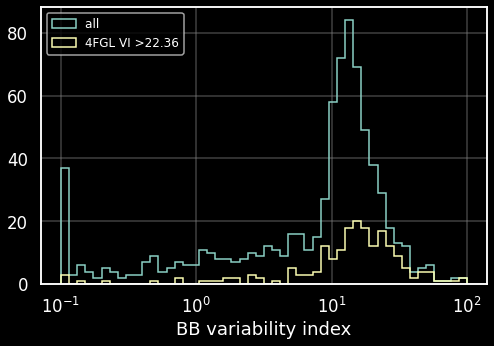

$\rightarrow$ Many (566/764) are above 95% CL (3.8) for 1 DOF.
<br>But the low range distribution does not look like chi-squared.<br>
Need a MC distribution for fraction of null set with 2 blocks.

In [ ]:
show(f"""## Study the Bayesian block variability index  """)

def bb_var_plot(df, ax=None):

     from scipy import stats
     fig, ax = plt.subplots(figsize=(8,5)) if ax is None else (ax.figure, ax)
     hkw = dict(x='bb_var', bins=np.logspace(-1,2, 51), histtype='step')
     ax.hist(data=df, **hkw, label='all ')
     ax.hist(data=df.query('variability>22.36'), **hkw, label='4FGL VI >22.36')

     # ax.axvline((cl_value:=stats.chi2(1).ppf(0.95)), ls=':', 
     #           label=f'95% CL value\n({cl_value:.2f})')
     ax.legend(loc='upper left',fontsize=12)
     ax.set(xlabel= 'BB variability index', xscale='log')
     return fig

from scipy import stats
cl_value=stats.chi2(1).ppf(0.95)
show_fig(bb_var_plot,df)
show(fr"""$\rightarrow$ Many ({np.sum(df.bb_var>cl_value)}/{len(df)}) are above 95% CL ({cl_value:.1f}) for 1 DOF.
     <br>But the low range distribution does not look like chi-squared.<br>
     Need a MC distribution for fraction of null set with 2 blocks.""")

In [51]:
show("""#### Get the LC info, replace 'poiss' with 'fit'  """)


class LC(dict):
    """ Make a class to encapsulate light curve stuff"""
    
    def __init__(self, d):
           
        from wtlike.poisson import Poisson
        
        # replace 'poiss' triple with Poisson object, 'fit'  
        if 'poiss' in d:    
            d['fit'] =  pd.Series(d['poiss']).apply(Poisson)
            d.pop('poiss')
        
        self['light_curve']= df = pd.DataFrame.from_dict(d) 

        # secondary
        assert len(d['t'])==2, 'Expect only nbb==2'
        fx = list(df.flux.values)
        self['time'], self['t2'] = list(df.tw.values)
        self['flux_ratio'] = fx[1]/fx[0] if fx[0]>0 else np.nan

        beta, sig_beta = [np.array(list(df[k].values)) for k in 'beta sig_beta'.split()]
        
        t =list(filter(lambda x: not np.isnan(x), beta/sig_beta))
        self['beta_flag'] = np.nan if len(t)==0 else max(t)
      
    
lcs = pd.Series(index=df.index, data= [(LC(vdb[uw_ref]['light_curve'])) for uw_ref in df.uw_name], name='light_curve')
show(""" Add columns except for "light_curve" to the 2-block DataFrame""")
for k,v in lcs.items():
    for kk, vv in v.items():
        if kk=='light_curve': continue
        df.loc[k,kk] = vv
    

#### Get the LC info, replace 'poiss' with 'fit'  

Add columns except for "light_curve" to the 2-block DataFrame

array([[<Axes: title={'center': 'beta_flag'}>]], dtype=object)

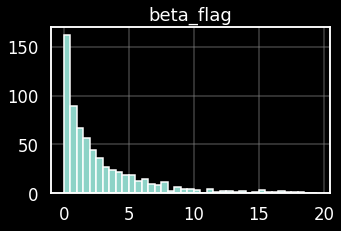

In [55]:
df.hist('beta_flag', bins=np.arange(0,20,0.5))

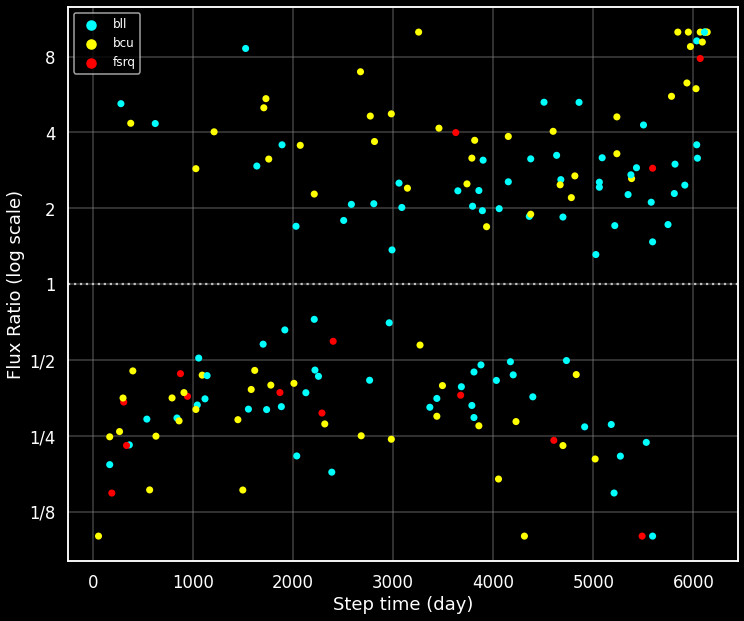

In [60]:
ratio_display(df.query('bb_var>4 & beta_flag<2'), hue_order='bll bcu fsrq'.split(), 
              palette='cyan yellow red'.split());

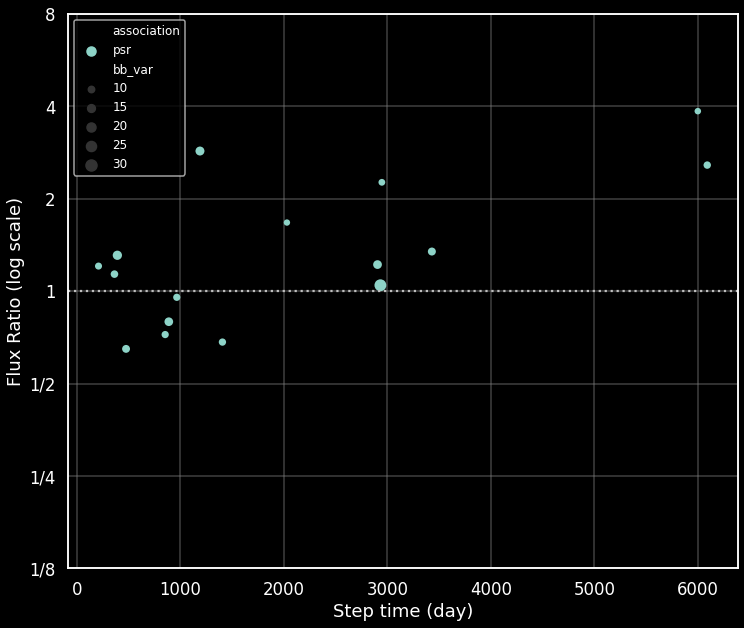

In [59]:
df_psr = df.query('association=="psr" & beta_flag<2').sort_index()
ratio_display(df_psr, #.query('bb_var>20'), 
            size='bb_var',size_norm=(10,40));

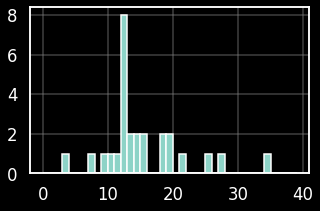

In [ ]:
plt.hist(df_psr.bb_var, bins=np.arange(0,40,1))
df_psr.query('bb_var>10')['ts bb_var time flux_ratio variability'.split()].to_csv('files/pulsars.csv')

## Compare numbers of 2-block light curves with the single blocks
There are two reasons for 2-BB light curves to be 
related to the 1-BB ones.
1) Background: It is a false positive generated by the
BB algorithm. (We need to examine this possibility with a MC.)
2) Science: The source must have been quiet for at least 8 years, compared with 15 for 
the 1-block set. The rates must be part of same variability spectrum.

Here are the total numbers, for each of our six 
association classes:

,nbb=1,nbb=2,ratio
bcu,575,195,0.339
bll,466,191,0.410
fsrq,61,28,0.459
other,219,45,0.205
psr,217,27,0.124
unid,1365,278,0.204


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ee147b79030>
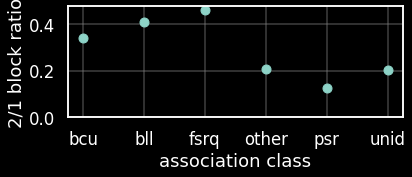

The distributions of the sizes of the steps.
The pulsar one should only reflect reason 1.

/home/burnett/miniconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ee147ccc8e0>
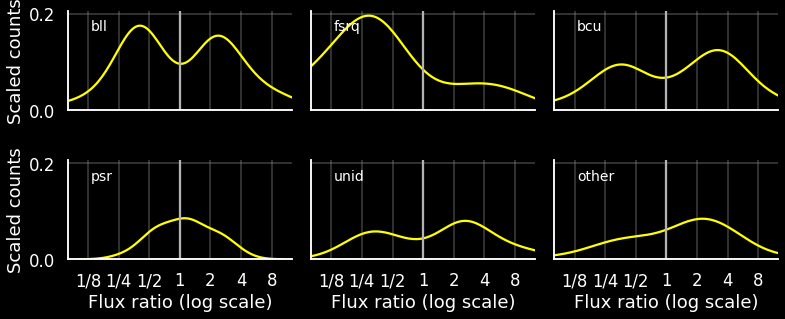

Notes:
* The range of the pulsar step sizes is  mostly limited to be less than 2.
* If the apparent pulsar steps are all spurious, its dristribution
above shouid be a component of all the others. This does not
appear to be the case, especially for the unid's.
* The asymmetry between up- and down-steps is dramatically
different. It appears from this that the most of the bcu's are 
BL Lacs, and a large proportion of the unid's are as well.

In [64]:
def block_2_1(dfx, fignum=3):
    show(f"""## Compare numbers of 2-block light curves with the single blocks
    There are two reasons for 2-BB light curves to be 
    related to the 1-BB ones.
    1) Background: It is a false positive generated by the
    BB algorithm. (We need to examine this possibility with a MC.)
    2) Science: The source must have been quiet for at least 8 years, compared with 15 for 
    the 1-block set. The rates must be part of same variability spectrum.
    
    Here are the total numbers, for each of our six 
    association classes:
    """)
    def get_unique(sclass, name=''):
        v,n = np.unique(sclass,  return_counts=True)
        df= pd.DataFrame.from_dict(
                dict(list(zip(v,n))), orient='index',
            )
        return df.rename(columns={0:name})
         
    ones, twos = dfx.query('nbb==1').copy(), dfx.query('nbb==2').copy()
    nbb1 = get_unique(ones.association, 'nbb=1')
    nbb2 = get_unique(twos.association, 'nbb=2')
    
    nbbstats = pd.concat([nbb1,nbb2], axis=1, )
    nbbstats.loc[:,'ratio'] = nbbstats.iloc[:,1]/nbbstats.iloc[:,0]
    show(nbbstats)
    fig,ax = plt.subplots(figsize=(6,2))
    ax.plot(nbbstats.ratio, 'o')
    ax.set(ylabel='2/1 block ratio', xlabel='association class', ylim=(0,None))
    show(fig)
    
    show(""" The distributions of the sizes of the steps.
    The pulsar one should only reflect reason 1.""")
    
    import warnings
    warnings.simplefilter("ignore", FutureWarning)
    
    df.loc[:,'log_ratio'] = np.log10(df.flux_ratio)
    col_order = 'bll fsrq bcu psr unid other'.split()
    sns.displot(df, x='log_ratio', # bins=np.linspace(-1,1,41),
                weights= 1/nbb1.loc[df.association].values.T[0],
                col='association',  col_wrap=3, 
                col_order=col_order,
                height=2.5, aspect=1.5, color='yellow',
                kind= 'kde', #element='step', fill=False,
    
               )
    for ax, col_name in zip(plt.gcf().axes, col_order):
        ax.set( xlabel='Flux ratio (log scale)', ylabel='Scaled counts') #, yscale='log')
        ax.axvline(0, color= "0.7"  , )
        ticks = np.log10(np.array([1/8,1/4, 1/2, 1, 2, 4,8]))
        ax.grid(color='0.5')
        ax.text(0.1, 0.8, col_name, fontsize=14, transform=ax.transAxes)
        ax.set(title='')
    ax.set(xlim=(-1.1,1.1),xticks=ticks, xticklabels='1/8 1/4 1/2 1 2 4 8'.split());
    
    show(ax.figure, fignum=fignum,
         caption="""Flux ratio KDE plots for each association 
    category. Counts are scaled by the inverse of the number of sources with nbb=1,
    so the total represents the fraction of nbb=2 to nbb=1. The pulsars are then 
    an estimate of the contribution of false positives to be applied to the others.
    """)
    show(f"""Notes:
    * The range of the pulsar step sizes is  mostly limited to be less than 2.
    * If the apparent pulsar steps are all spurious, its dristribution
    above shouid be a component of all the others. This does not
    appear to be the case, especially for the unid's.
    * The asymmetry between up- and down-steps is dramatically
    different. It appears from this that the most of the bcu's are 
    BL Lacs, and a large proportion of the unid's are as well.
    
    """)
block_2_1(dfx)

### J0437.2-4715



<details  class="nbdoc-description" >  <summary> Analysis printout for J0437.2-4715 (PSR J0437-4715) </summary>  <div style="margin-left: 25px;"><pre>Source name, "J0437.2-4715" <br>	Parsing J0437.2-4715<br>	is closest to uw1410 source "PSR J0437-4715", 0.02 deg away<br>SourceData:  PSR J0437-4715: Restoring from cache with key "PSR J0437-4715_data"<br>SourceData: Source PSR J0437-4715 with:<br>	 data:       123,943 photons from 2008-08-04 to 2025-05-23<br>	 exposure: 4,155,349 intervals,  average effective area 3481 cm^2 for 124.1 Ms<br>	 rates:  source 2.07e-08/s, background 2.66e-07/s, TS 6658.2<br>CellData.rebin: Bin photon data into 204 30-day bins from 54683.0 to 60803.0<br>LightCurve: select 204 cells for fitting with e&gt;150.000 & n&gt;2<br>CellData.rebin: Bin photon data into 204 30-day bins from 54683.0 to 60803.0<br>LightCurve: select 204 cells for fitting with e&gt;150.000 & n&gt;2<br>Bayesian Blocks: partitioning 204  cells using LikelihoodFitness with penalty 5%<br>	found 2 / 204 blocks.<br>LightCurve: Loaded 2 / 2 cells for fitting<br>CellData.rebin: Bin photon data into 588960 15-min bins from 54683.0 to 60818.0<br></pre></div> </details>

<details  class="nbdoc-description" >  <summary> uw1410 (PSR J0437-4715) <font color=>(sep, r95 =1.2, 1.2 arcmin )</font> </summary>  <div style="margin-left: 25px;"><pre>jname                                      J0437.3-4715<br>fk5                                   ( 69.327,-47.258)<br>galactic                              (253.401,-41.956)<br>specfunc    PLSuperExpCutoff(4.84e-11, 0.84, 292, 0.67)<br>e0                                              764.463<br>eflux100                                       1.76e-11<br>ts                                             6658.197<br>fitqual                                          10.250<br>locqual                                           0.010<br>aprob                                             1.000<br>r95                                               0.020<br>sep                                               0.020<br>Name: PSR J0437-4715, dtype: object<br></pre></div> </details>
<details  class="nbdoc-description" >  <summary> 4FGL-DR4 (4FGL J0437.2-4715) <font color=>(sep, r95 =0.6, 1.6 arcmin )</font> </summary>  <div style="margin-left: 25px;"><pre>fk5                                         ( 69.314,-47.255)<br>galactic                                    (253.397,-41.965)<br>specfunc        PLSuperExpCutoff4(1.10e-11, 1.92, 0.71, 0.67)<br>pivot                                                 619.984<br>eflux                                                1.78e-11<br>significance                                           76.909<br>flags                                                      {}<br>variability                                            11.201<br>assoc_prob                                              1.000<br>class1                                                    MSP<br>assoc1_name                                    PSR J0437-4715<br>r95                                                     0.026<br>sep                                                     0.010<br>Name: 4FGL J0437.2-4715, dtype: object<br></pre></div> </details>
<div style="margin-left: 10px"><a id="Figure_None"/><figure style="margin-left: 10px">   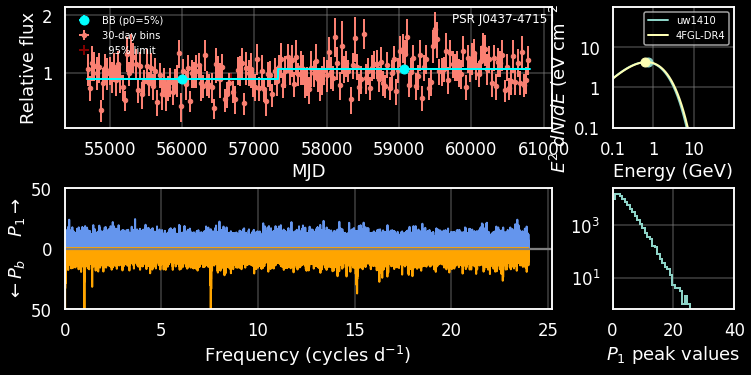 <br> </figure></div>
<details >  <summary> 2 nearby variable sources </summary>  <div style="margin-left: 25px"><table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>sep</th>
      <th>glon</th>
      <th>glat</th>
      <th>significance</th>
      <th>variability</th>
    </tr>
    <tr>
      <th>4FGL-DR4</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>4FGL J0438.9-4521</th>
      <td>1.916</td>
      <td>250.834</td>
      <td>-41.766</td>
      <td>32.876</td>
      <td>61.073</td>
    </tr>
    <tr>
      <th>4FGL J0451.8-4651</th>
      <td>2.521</td>
      <td>252.735</td>
      <td>-39.503</td>
      <td>17.181</td>
      <td>206.319</td>
    </tr>
  </tbody>
</table></div> </details>
<details >  <summary> 2 BB fits <font color=red>Check beta:  max beta/sig_beta is 17.1</font> </summary>  <div style="margin-left: 25px"><table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>t</th>
      <th>tw</th>
      <th>ts</th>
      <th>flux</th>
      <th>errors</th>
      <th>flux</th>
      <th>beta</th>
      <th>sig_beta</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>56003.000</td>
      <td>2640.000</td>
      <td>2880.200</td>
      <td>0.896</td>
      <td>(-0.026, 0.026)</td>
      <td>1.080</td>
      <td>-0.113</td>
      <td>0.005</td>
    </tr>
    <tr>
      <td>59063.000</td>
      <td>3480.000</td>
      <td>5200.700</td>
      <td>1.071</td>
      <td>(-0.023, 0.023)</td>
      <td>0.953</td>
      <td>0.071</td>
      <td>0.004</td>
    </tr>
  </tbody>
</table></div> </details>
<div style="margin-left: 25px;"><pre>No FFT peaks satisfying p1&gt;25 & 10&gt;f&gt;0.01</pre></div>



In [ ]:
from wtlike.interface import examine_source
examine_source('J0437.2-4715')

/home/burnett/miniconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


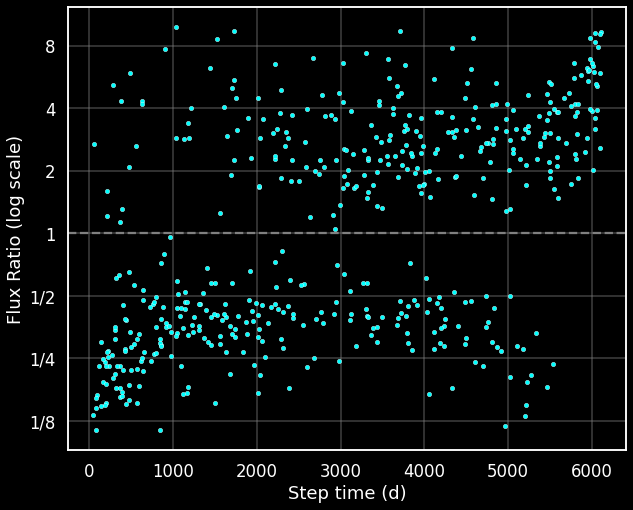

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))
sns.scatterplot(data=df.query('0.1<flux_ratio<10 & bb_var>4 '), 
                y=np.log10(df.flux_ratio), x='time', s=20, color='cyan')
ax.axhline(0, ls='--', color='0.5')
ticks = np.log10(np.array([1/8,1/4, 1/2, 1, 2, 4,8]))
ax.set( yticks=ticks, yticklabels='1/8 1/4 1/2 1 2 4 8'.split())
ax.set(xlabel = 'Step time (d)',ylabel='Flux Ratio (log scale)');


In [ ]:
np.unique(df.time+df.t2)

array([6139., 6146.])

In [ ]:
k = dfx.iloc[0].uw_name
k, vdb[k]

('J0000.1-7354',
 {'light_curve': {'t': {0: 57756.0},
   'tw': {0: 6146.0},
   'ts': {0: 62.5},
   'flux': {0: 0.9983},
   'errors': {0: (-0.163, 0.172)},
   'flux_beta': {0: 0.9989182617506163},
   'beta': {0: -9.814383166871152e-05},
   'sig_beta': {0: 0.002756293397396803},
   'poiss': {0: [0.9982663211682018, 74.75692509611243, 1.0908637402773094]}},
  'variability': 0.00010749371153906395,
  'fft_peaks': {'f': {}, 'p1': {}},
  'nearby': {'sep': {},
   'glon': {},
   'glat': {},
   'significance': {},
   'variability': {}},
  'porb': nan,
  'nbb': 1,
  'near': 5})

In [ ]:
df.iloc[0]

delta              7.96e-04
ts                  702.004
r95                   0.023
glat                -67.305
glon                 89.031
eflux100           6.97e-12
nbb                       2
class1                  bll
variability          51.742
pindex                2.076
curvature             0.030
e0                 1989.840
sin_b                -0.923
uw_name        J0001.2-0747
association             bll
category                bll
bb_var               51.543
time               3787.000
t2                 2359.000
flux_ratio            0.330
Name: 4FGL J0001.2-0747, dtype: object

In [ ]:

def select_single_step(dfx, margin=1000, nbb_max=4):
    show("""### Detect the single-steppers
Here I select BB light curves which start and end with long blocks, and record the ratio
of the two levels (the steps), and the position of the transition.
The light curves were generated with a bin width of 7 days, so the "step" position
must be at a bin boundary, the boundary position depending on the BB algorithm, its uncertainty TBD.
Ratios close to 1.0 are possibly an artifact of the BB procedure, this needs study.
""")
    ass = dfx.association.values
    tss = dfx.ts.values
    names = dfx.index
    nbbs = dfx.nbb
    def make_df(x):
        if x is None: return None
        return pd.DataFrame.from_dict(x)
    lcs = [make_df(vdb[uw_name]['light_curve']) for uw_name in dfx.uw_name]
    
    dd = dict()
    for name, lc, stype, ts, nbb in zip(names, lcs, ass, tss, nbbs):
        if lc is None or len(lc)==1 or len(lc)>nbb_max: continue
        
        v = lc.tw.values
        m = np.sum(v[1:-1])
        a,b = lc.flux.values[0], lc.flux.values[-1] # needed after rename column [:,0]
    
        if (a*b>0) & (v[0]>=margin) & (v[-1]>=margin):
            dd[name] = dict(flux_ratio=b/a, time=v[0], t2=v[-1], tm=m,
                            ts=ts, association=stype, nbb=nbb)
    df = pd.DataFrame.from_dict(dd, orient='index') 

    df.loc[:,'eflux'] = dfx.loc[df.index, 'eflux100']

    show(f"""Apply margin={margin} days and nbb_max={nbb_max}: <br>Found {len(df)} candidates, with the association categories""") 
    assert len(df)>0, 'Failed to find any?'
    v,n = np.unique(df.association,  return_counts=True)
    show(pd.Series(dict(list(zip(v,n))), name=''))
    return df
df = select_single_step(dfx)


### Detect the single-steppers
Here I select BB light curves which start and end with long blocks, and record the ratio
of the two levels (the steps), and the position of the transition.
The light curves were generated with a bin width of 7 days, so the "step" position
must be at a bin boundary, the boundary position depending on the BB algorithm, its uncertainty TBD.
Ratios close to 1.0 are possibly an artifact of the BB procedure, this needs study.

Apply margin=1000 days and nbb_max=4: <br>Found 1074 candidates, with the association categories

,bcu,bll,fsrq,other,psr,unid
,305,307,65,42,38,317


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ee15c5b2470>
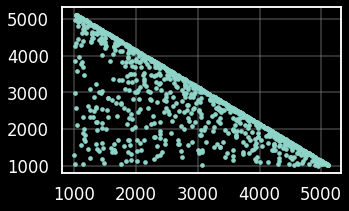

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ee15c26e350>
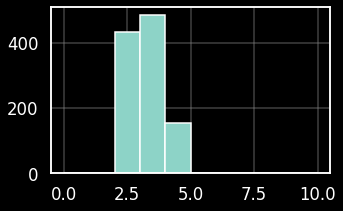

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ee15af3e080>
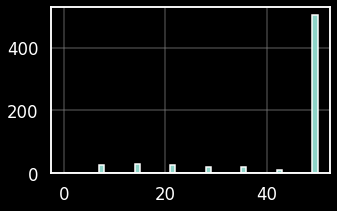

In [ ]:
plt.scatter(df.time, df.t2, s=10); show(plt.gcf())

plt.hist(df.nbb, bins=np.linspace(0,10,11)); show(plt.gcf())
#plt.hist(df.tm, bins=np.linspace(0,100,25)); 
plt.hist(df.query('nbb>2').tm.clip(0,50), bins=np.linspace(0,50,51)); 
show(plt.gcf())

In [ ]:

def make_df(x):
    if x is None: return None
    return pd.DataFrame.from_dict(x)
lcs = [make_df(vdb[uw_name]['light_curve']) for uw_name in dfx.uw_name]

In [ ]:
from wtlike.poisson import Poisson
lcs[0]['poiss'].apply(Poisson)

0    0.998[1+0.163-0.172]
Name: poiss, dtype: object

In [ ]:
show(f"""* Extract light curves""")    
def make_df(x):
        if x is None: return None
        return pd.DataFrame.from_dict(x)
lcs = [make_df(vdb[uw_name]['light_curve']) for uw_name in dfx.uw_name]

* Extract light curves

In [ ]:
from wtlike.poisson import Poisson
lcs[0].poiss.apply(Poisson)

0    0.998[1+0.163-0.172]
Name: poiss, dtype: object

In [ ]:
for key,value in vdb.items():
    near = value['near']  
    print(near)    
    break

5


In [ ]:
show(f"""### Extract potential transitions: require:
    * At least 2 and less than 5 blocks 
    * at least {(end_size:=1000)} days at each end
    * No more than {(transition_size:=100)} days in the middle
    """)
lct = dict()
for name, lc in zip(dfx.index,lcs):
    if lc is None or len(lc)<2 or len(lc)>5: continue
    # start, end block sizes
    sb, eb = lc.tw[0], lc.tw.values[-1]
    if sb<end_size or eb<end_size: continue
    mb = np.sum(lc.tw.values[1:-1])
    if mb>transition_size: continue
    ce = dfx.loc[name]

    fluxes =  lc.flux.values
    a,b = fluxes[0], fluxes[-1]
    if a==0: continue
    lct[name] = (sb,mb,eb, len(lc),
                  ce['association'], ce['eflux100'], ce['e0'],   b/a, sb+0.5*mb  )
    
dft = pd.DataFrame.from_dict(lct, orient='index',
                     columns=['start_block', 'middle_block', 'end_block', 'blocks',
                               'association', 'eflux', 'epeak','flux_ratio', 'time'])

show(rf"""$\rightarrow$ Extracted subset of {len(dft)} light curves, with association categories.""")
v,n = np.unique(dft.association,  return_counts=True)
show(pd.Series(dict(list(zip(v,n))), name=''))


### Extract potential transitions: require:
* At least 2 and less than 5 blocks 
* at least 1000 days at each end
* No more than 100 days in the middle

$\rightarrow$ Extracted subset of 646 light curves, with association categories.

,bcu,bll,fsrq,other,psr,unid
,180,163,32,28,28,215


/home/burnett/miniconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


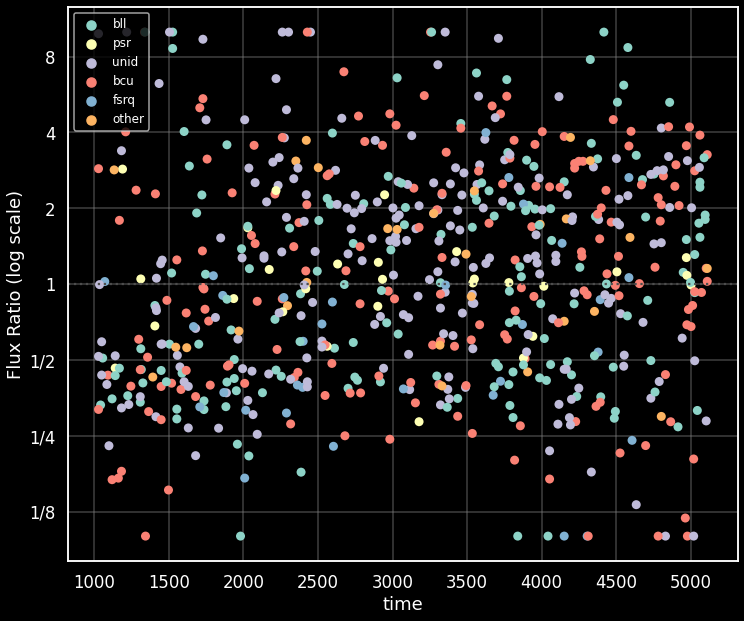

In [ ]:
def ratio_display(df,  ax=None, **kwargs):
    
    eflux = df.eflux
    # sns.set_theme(font_scale=1.2)
    fig, ax = plt.subplots(figsize = (12,10)) if ax is None else (ax.figure, ax)
    r = df.flux_ratio
    
    sns.scatterplot(df, ax=ax, y=np.log10(r).clip(-1,1), 
                    x='time', hue='association', 
                    **kwargs, edgecolor='none',
                    # size=np.log10(eflux), sizes=(10, 150),
                )
    ax.set(#xlim=(-50,800), xlabel='Step time (Fermi week)', 
        
        ylabel='Flux Ratio (log scale)')
    ax.axhline(0, color="0.3", ls=':' )
    ticks = np.log10(np.array([1/8,1/4, 1/2, 1, 2, 4,8]))
    ax.set( yticks=ticks, yticklabels='1/8 1/4 1/2 1 2 4 8'.split())
    ax.legend(loc='upper left', fontsize=12,)
    return fig

ratio_display(dft);

In [ ]:
# show(f"""* Put them all into the cache""")
# for name in dft.index:
#     print(name, end='')
#     try:
#         WtLike(name)
#     finally:
#         continue

### J0022.0-5921



<details  class="nbdoc-description" >  <summary> Analysis printout for J0022.0-5921 (03bH-0197) </summary>  <div style="margin-left: 25px;"><pre>Source name, "J0022.0-5921" <br>	Parsing J0022.0-5921<br>	is closest to uw1410 source "03bH-0197", 0.11 deg away<br>SourceData:  03bH-0197: Restoring from cache with key "03bH-0197_data"<br>SourceData: Source 03bH-0197 with:<br>	 data:       101,424 photons from 2008-08-04 to 2025-05-23<br>	 exposure: 4,292,203 intervals,  average effective area 3446 cm^2 for 128.2 Ms<br>	 rates:  source 2.85e-10/s, background 2.29e-07/s, TS 48.4<br>CellData.rebin: Bin photon data into 204 30-day bins from 54683.0 to 60803.0<br>LightCurve: select 204 cells for fitting with e&gt;150.000 & n&gt;2<br>CellData.rebin: Bin photon data into 204 30-day bins from 54683.0 to 60803.0<br>LightCurve: select 204 cells for fitting with e&gt;150.000 & n&gt;2<br>Bayesian Blocks: partitioning 204  cells using LikelihoodFitness with penalty 5%<br>	found 1 / 204 blocks.<br>LightCurve: Loaded 1 / 1 cells for fitting<br>CellData.rebin: Bin photon data into 588960 15-min bins from 54683.0 to 60818.0<br></pre></div> </details>

<details  class="nbdoc-description" >  <summary> uw1410 (03bH-0197) <font color=red>(sep, r95 =6.3, 3.1 arcmin )</font> </summary>  <div style="margin-left: 25px;"><pre>jname                                  J0021.2-5917<br>fk5                               (  5.323,-59.295)<br>galactic                          (310.075,-57.413)<br>specfunc    LogParabola(3.74e-15, 1.89, 0.13, 5562)<br>e0                                         5562.163<br>eflux100                                   8.22e-13<br>ts                                           48.351<br>fitqual                                       5.760<br>locqual                                       0.690<br>aprob                                             0<br>r95                                           0.052<br>sep                                           0.106<br>Name: 03bH-0197, dtype: object<br></pre></div> </details>
<details  class="nbdoc-description" >  <summary> 4FGL-DR4 (4FGL J0022.0-5921) <font color=>(sep, r95 =0.7, 6.7 arcmin )</font> </summary>  <div style="margin-left: 25px;"><pre>fk5                    (  5.522,-59.350)<br>galactic               (309.870,-57.381)<br>specfunc        PowerLaw(1.56e-13, 2.42)<br>pivot                           1434.352<br>eflux                           3.54e-12<br>significance                      12.374<br>flags                                {2}<br>variability                       19.921<br>assoc_prob                             0<br>class1                                  <br>assoc1_name                             <br>r95                                0.112<br>sep                                0.011<br>Name: 4FGL J0022.0-5921, dtype: object<br></pre></div> </details>
<div style="margin-left: 10px"><a id="Figure_None"/><figure style="margin-left: 10px">   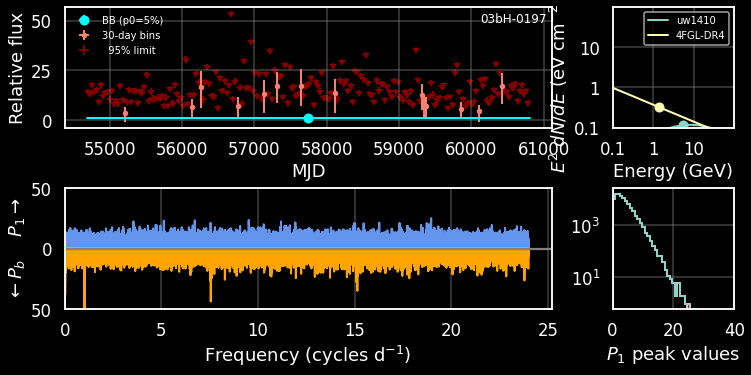 <br> </figure></div>
<details >  <summary> 1 nearby variable sources </summary>  <div style="margin-left: 25px"><table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>sep</th>
      <th>glon</th>
      <th>glat</th>
      <th>significance</th>
      <th>variability</th>
    </tr>
    <tr>
      <th>4FGL-DR4</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>4FGL J0019.2-5640</th>
      <td>2.692</td>
      <td>311.751</td>
      <td>-59.891</td>
      <td>14.666</td>
      <td>108.181</td>
    </tr>
  </tbody>
</table></div> </details>
<details >  <summary> 1 BB fits  </summary>  <div style="margin-left: 25px"><table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>t</th>
      <th>tw</th>
      <th>ts</th>
      <th>flux</th>
      <th>errors</th>
      <th>flux</th>
      <th>beta</th>
      <th>sig_beta</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>57743.000</td>
      <td>6120.000</td>
      <td>30.700</td>
      <td>1.000</td>
      <td>(-0.234, 0.255)</td>
      <td>1.002</td>
      <td>7.31e-06</td>
      <td>0.003</td>
    </tr>
  </tbody>
</table></div> </details>
<div style="margin-left: 25px;"><pre>No FFT peaks satisfying p1&gt;25 & 10&gt;f&gt;0.01</pre></div>



In [ ]:
from wtlike.interface import examine_source
examine_source('J0022.0-5921')